In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import random
import datetime

In [3]:
spark = SparkSession.builder.appName("DataGenerationColab").getOrCreate()

In [4]:
days = 7
sessions_per_day = 1000
users_count = 500
output_base = "data/applications-gen/raw"

real_apps = ["Chrome", "Edge", "Firefox", "Slack", "VSCode", "Teams", "Steam"]
power_modes = ["high", "balanced", "powersave"]
start_date = datetime.date(2025, 12, 3)
dates = [start_date + datetime.timedelta(days=i) for i in range(days)]

all_users = [f"user_{i}" for i in range(users_count)]
all_devices = [f"device_{i}" for i in range(users_count)]

In [5]:
for date in dates:
    date_str = str(date)
    print(f"Generating data for {date_str}...")

Generating data for 2025-12-03...
Generating data for 2025-12-04...
Generating data for 2025-12-05...
Generating data for 2025-12-06...
Generating data for 2025-12-07...
Generating data for 2025-12-08...
Generating data for 2025-12-09...


In [13]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import random
import datetime

spark = SparkSession.builder.appName("DataGenerationFull").getOrCreate()

days = 7
sessions_per_day = 1000
users_count = 500
output_base = "data/applications-gen/raw"
real_apps = ["Chrome", "Edge", "Firefox", "Slack", "VSCode", "Teams", "Steam"]
countries = ["AM", "US", "DE", "FR", "UK", "KZ"]

start_date = datetime.date(2025, 12, 3)
dates = [start_date + datetime.timedelta(days=i) for i in range(days)]
all_users = [f"user_{i}" for i in range(users_count)]
all_devices = [f"device_{i}" for i in range(users_count)]

for date in dates:
    date_str = str(date)
    print(f"Processing date: {date_str}")

    active_users_count = int(users_count * 0.7)
    detected_devices = random.sample(all_devices, active_users_count)
    detected_users = random.sample(all_users, active_users_count)

    sessions_rows = []
    for i in range(sessions_per_day):
        u = random.choice(detected_users)
        d = random.choice(detected_devices)
        ts = datetime.datetime.combine(date, datetime.time()) + datetime.timedelta(seconds=random.randint(0, 86400))
        duration = float(random.randint(60, 3600))
        if random.random() < 0.05: duration = -100.0

        sessions_rows.append((u, d, f"sess_{date_str}_{i}", ts, ts, duration, random.choice(real_apps)))

    sess_schema = StructType([
        StructField("userid", StringType()), StructField("deviceid", StringType()),
        StructField("sessionid", StringType()), StructField("clientTs", TimestampType()),
        StructField("serverTs", TimestampType()), StructField("sessionDuration", DoubleType()),
        StructField("applicationName", StringType())
    ])
    spark.createDataFrame(sessions_rows, sess_schema).write.mode("overwrite").parquet(f"{output_base}/sessions/{date_str}")

    hw_rows = [(d, random.choice(["Intel i7", "M2", "Ryzen 9"]), random.choice([8, 16, 32]),
                random.choice(["Windows 11", "macOS", "Linux"]), "Laptop") for d in detected_devices]
    spark.createDataFrame(hw_rows, ["deviceid", "cpu", "ramGb", "os", "formFactor"]).write.mode("overwrite").parquet(f"{output_base}/hardware/{date_str}")

    apps_rows = [(d, {app: f"{random.randint(1, 5)}.0" for app in random.sample(real_apps, random.randint(2, 5))}) for d in detected_devices]
    apps_schema = StructType([
        StructField("deviceid", StringType()),
        StructField("installedApps", MapType(StringType(), StringType()))
    ])
    spark.createDataFrame(apps_rows, apps_schema).write.mode("overwrite").parquet(f"{output_base}/applications/{date_str}")

    user_rows = [(u, random.randint(18, 65), random.choice(countries)) for u in detected_users]
    user_schema = StructType([
        StructField("userid", StringType()),
        StructField("age", IntegerType()),
        StructField("country", StringType())
    ])
    spark.createDataFrame(user_rows, user_schema).write.mode("overwrite").parquet(f"{output_base}/users/{date_str}")

    print(f"Finished {date_str}")

print("\nDone")

Processing date: 2025-12-03
Finished 2025-12-03
Processing date: 2025-12-04
Finished 2025-12-04
Processing date: 2025-12-05
Finished 2025-12-05
Processing date: 2025-12-06
Finished 2025-12-06
Processing date: 2025-12-07
Finished 2025-12-07
Processing date: 2025-12-08
Finished 2025-12-08
Processing date: 2025-12-09
Finished 2025-12-09

Done


In [14]:
#Create Day-0 State for userDevice Table

In [17]:
from pyspark.sql import functions as F
import os

raw_path = "data/applications-gen/raw"
state_path = "data/applications-gen/states/userDevice"
first_date = "2025-12-03"

os.makedirs(state_path, exist_ok=True)

sessions = spark.read.parquet(f"{raw_path}/sessions/{first_date}")
hardware = spark.read.parquet(f"{raw_path}/hardware/{first_date}")
apps = spark.read.parquet(f"{raw_path}/applications/{first_date}")

user_device_base = sessions.groupBy("userid", "deviceid").agg(
    F.min("serverTs").alias("registerTs"),
    F.max("serverTs").alias("lastActivityTs"),
    F.max("serverTs").alias("lastSessionTs")
)

day_0_state = user_device_base \
    .join(hardware, "deviceid", "left") \
    .join(apps, "deviceid", "left") \
    .select(
        "userid",
        "deviceid",
        "registerTs",
        "lastActivityTs",
        "lastSessionTs",
        F.col("installedApps").alias("applications"),
        F.array(
            F.col("cpu"),
            F.col("ramGb").cast("string"),
            F.col("os"),
            F.col("formFactor")
        ).alias("hardware")
    )

day_0_state.write.mode("overwrite").parquet(f"{state_path}/{first_date}")
print(f"Day-0 state created for {first_date}")

Day-0 state created for 2025-12-03


In [18]:
#Daily Enricher Function (Fixed)

In [21]:
def enrich_user_device(current_date, previous_date):
    prev_state = spark.read.parquet(f"{state_path}/{previous_date}")

    new_sessions = spark.read.parquet(f"{raw_path}/sessions/{current_date}")
    new_hw = spark.read.parquet(f"{raw_path}/hardware/{current_date}")
    new_apps = spark.read.parquet(f"{raw_path}/applications/{current_date}")

    new_data = new_sessions.groupBy("userid", "deviceid").agg(
        F.min("serverTs").alias("new_reg"),
        F.max("serverTs").alias("new_act")
    ).join(new_hw, "deviceid", "left").join(new_apps, "deviceid", "left")

    enriched = prev_state.join(new_data, ["userid", "deviceid"], "full") \
        .select(
            "userid",
            "deviceid",
            F.coalesce(F.col("registerTs"), F.col("new_reg")).alias("registerTs"),
            F.coalesce(F.col("new_act"), F.col("lastActivityTs")).alias("lastActivityTs"),
            F.coalesce(F.col("new_act"), F.col("lastSessionTs")).alias("lastSessionTs"),
            F.coalesce(F.col("installedApps"), F.col("applications")).alias("applications"),
            F.coalesce(
                F.col("hardware"),
                F.array(
                    F.col("cpu"),
                    F.col("ramGb").cast("string"),
                    F.col("os"),
                    F.col("formFactor")
                )
            ).alias("hardware")
        )

    enriched.write.mode("overwrite").parquet(f"{state_path}/{current_date}")
    print(f"Successfully enriched state for {current_date}")

In [22]:
#Run Daily Enrichment Loop

In [23]:
for i in range(1, len(dates)):
    current = str(dates[i])
    previous = str(dates[i-1])
    enrich_user_device(current, previous)

Successfully enriched state for 2025-12-04
Successfully enriched state for 2025-12-05
Successfully enriched state for 2025-12-06
Successfully enriched state for 2025-12-07
Successfully enriched state for 2025-12-08
Successfully enriched state for 2025-12-09


In [24]:
# Aggregator

In [25]:
#Cumulative Number of Users Aggregation

In [26]:
def aggregate_total_n_of_users_so_far_daily(date):
    state_df = spark.read.parquet(f"data/applications-gen/states/userDevice/{date}")
    return state_df.select("userid").distinct().count()

In [28]:
result_09 = aggregate_total_n_of_users_so_far_daily("2025-12-09")
print(f"Total cumulative users so far: {result_09}")

Total cumulative users so far: 499


In [29]:
print("Date       | Total Users")
print("-----------|------------")

for date_obj in dates:
    d_str = str(date_obj)
    count = aggregate_total_n_of_users_so_far_daily(d_str)
    print(f"{d_str} | {count}")

Date       | Total Users
-----------|------------
2025-12-03 | 332
2025-12-04 | 439
2025-12-05 | 477
2025-12-06 | 491
2025-12-07 | 496
2025-12-08 | 497
2025-12-09 | 499


In [32]:
#Define the Function

In [33]:
from pyspark.sql.functions import col, size, array_except, map_keys, sum

def aggregate_n_of_installs_uninstalls_daily(current_date, previous_date):
    state_path = "data/applications-gen/states/userDevice"

    curr = spark.read.parquet(f"{state_path}/{current_date}")
    prev = spark.read.parquet(f"{state_path}/{previous_date}")

    joined = curr.select("deviceid", col("applications").alias("curr_apps")) \
        .join(prev.select("deviceid", col("applications").alias("prev_apps")), "deviceid", "full")

    res = joined.select(
        size(array_except(map_keys(col("curr_apps")), map_keys(col("prev_apps")))).alias("installs"),
        size(array_except(map_keys(col("prev_apps")), map_keys(col("curr_apps")))).alias("uninstalls")
    ).agg(
        sum("installs").alias("total_installs"),
        sum("uninstalls").alias("total_uninstalls")
    )

    return res

In [34]:
#Execution Loop for Installs/Uninstalls

In [37]:
print(f"{'Date':<12} | {'Installs':<12} | {'Uninstalls':<12}")
print("-" * 40)

for i in range(1, len(dates)):
    curr_d = str(dates[i])
    prev_d = str(dates[i-1])

    # Կանչում ենք ֆունկցիան
    stats_df = aggregate_n_of_installs_uninstalls_daily(curr_d, prev_d)

    # Վերցնում ենք արդյունքը DataFrame-ից
    row = stats_df.first()

    installs = row['total_installs'] if row['total_installs'] else 0
    uninstalls = row['total_uninstalls'] if row['total_uninstalls'] else 0

    print(f"{curr_d:<12} | {installs:<12} | {uninstalls:<12}")

Date         | Installs     | Uninstalls  
----------------------------------------
2025-12-04   | 3452         | 3583        
2025-12-05   | 13988        | 13735       
2025-12-06   | 30817        | 31061       
2025-12-07   | 54215        | 54414       
2025-12-08   | 83623        | 84711       
2025-12-09   | 119968       | 121114      


In [38]:
import pandas as pd
import matplotlib.pyplot as plt

data_for_viz = []

for i in range(1, len(dates)):
    curr_d = str(dates[i])
    prev_d = str(dates[i-1])

    # Ստանում ենք տվյալները քո ֆունկցիաներից
    users_count = aggregate_total_n_of_users_so_far_daily(curr_d)
    stats_df = aggregate_n_of_installs_uninstalls_daily(curr_d, prev_d)
    row = stats_df.first()

    data_for_viz.append({
        "Date": curr_d,
        "Total_Users": users_count,
        "Installs": row['total_installs'] if row['total_installs'] else 0,
        "Uninstalls": row['total_uninstalls'] if row['total_uninstalls'] else 0
    })

df_viz = pd.DataFrame(data_for_viz)

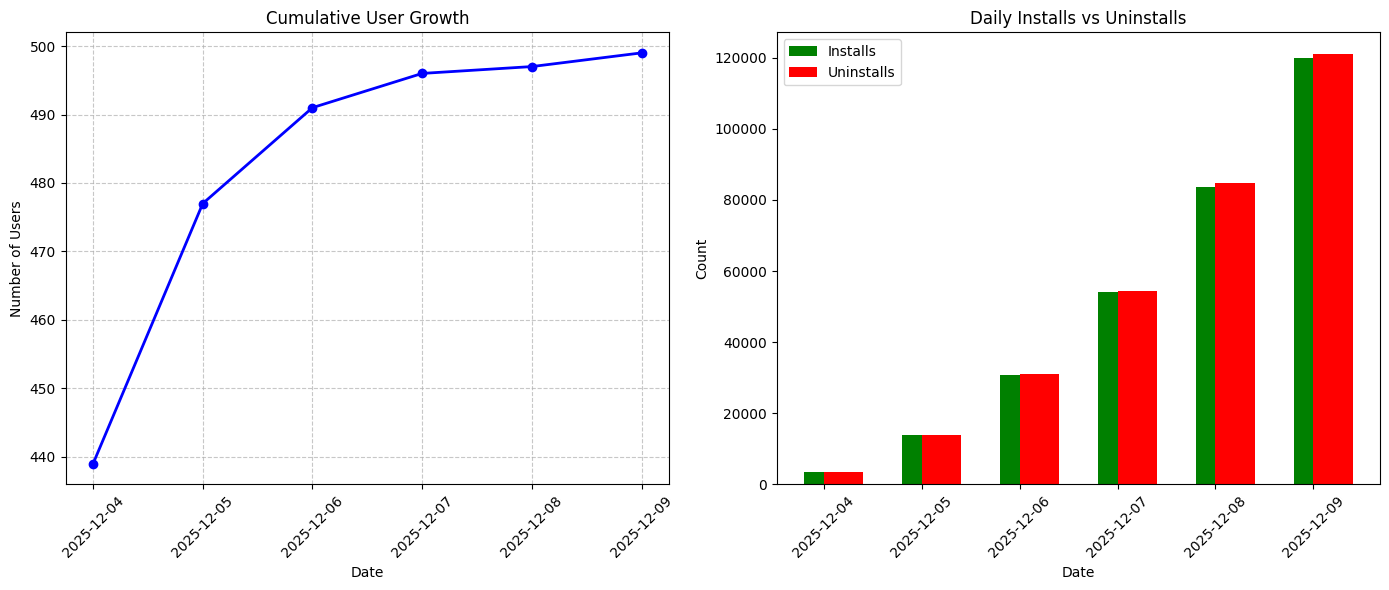

In [39]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(df_viz['Date'], df_viz['Total_Users'], marker='o', color='b', linestyle='-', linewidth=2)
plt.title('Cumulative User Growth')
plt.xlabel('Date')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
x = range(len(df_viz['Date']))
plt.bar(x, df_viz['Installs'], width=0.4, label='Installs', color='green', align='center')
plt.bar(x, df_viz['Uninstalls'], width=0.4, label='Uninstalls', color='red', align='edge')
plt.xticks(x, df_viz['Date'], rotation=45)
plt.title('Daily Installs vs Uninstalls')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

In [40]:
#Data Quality check

In [42]:
#Define logical_check() Function

In [41]:
def run_logical_dq_checks(date):
    df = spark.read.parquet(f"data/applications-gen/raw/sessions/{date}")

    negative_duration = df.filter(F.col("sessionDuration") < 0).count()

    null_users = df.filter(F.col("userid").isNull()).count()

    future_sessions = df.filter(F.col("serverTs") > F.current_timestamp()).count()

    issues = []
    if negative_duration > 0:
        issues.append(f"Negative session duration found: {negative_duration} rows")
    if null_users > 0:
        issues.append(f"Missing UserIDs found: {null_users} rows")
    if future_sessions > 0:
        issues.append(f"Future timestamps detected: {future_sessions} rows")

    print(f"--- DQ Report for {date} ---")
    if not issues:
        print("Status: PASSED (No logical issues found)")
    else:
        print("Status: FAILED")
        for issue in issues:
            print(f"- {issue}")

    return issues

In [43]:
all_issues_found = False

for date_obj in dates:
    d_str = str(date_obj)
    issues = run_logical_dq_checks(d_str)
    if issues:
        all_issues_found = True
    print("\n")

if not all_issues_found:
    print("Final Result: All raw datasets passed logical DQ checks!")

--- DQ Report for 2025-12-03 ---
Status: FAILED
- Negative session duration found: 44 rows


--- DQ Report for 2025-12-04 ---
Status: FAILED
- Negative session duration found: 45 rows


--- DQ Report for 2025-12-05 ---
Status: FAILED
- Negative session duration found: 41 rows


--- DQ Report for 2025-12-06 ---
Status: FAILED
- Negative session duration found: 51 rows


--- DQ Report for 2025-12-07 ---
Status: FAILED
- Negative session duration found: 52 rows


--- DQ Report for 2025-12-08 ---
Status: FAILED
- Negative session duration found: 58 rows


--- DQ Report for 2025-12-09 ---
Status: FAILED
- Negative session duration found: 48 rows




In [44]:
# Դիտարկենք սխալ տվյալները մեկ օրվա օրինակով
df_bad_data = spark.read.parquet("data/applications-gen/raw/sessions/2025-12-03")
df_bad_data.filter(F.col("sessionDuration") < 0).show(5)

+--------+----------+-------------------+-------------------+-------------------+---------------+---------------+
|  userid|  deviceid|          sessionid|           clientTs|           serverTs|sessionDuration|applicationName|
+--------+----------+-------------------+-------------------+-------------------+---------------+---------------+
|user_439|device_241|sess_2025-12-03_526|2025-12-03 19:26:26|2025-12-03 19:26:26|         -100.0|          Slack|
|user_236|device_201|sess_2025-12-03_556|2025-12-03 19:12:34|2025-12-03 19:12:34|         -100.0|          Teams|
|user_136|device_423|sess_2025-12-03_577|2025-12-03 13:24:22|2025-12-03 13:24:22|         -100.0|        Firefox|
|user_173| device_12|sess_2025-12-03_589|2025-12-03 11:45:55|2025-12-03 11:45:55|         -100.0|           Edge|
|user_330|device_337|sess_2025-12-03_635|2025-12-03 22:35:07|2025-12-03 22:35:07|         -100.0|          Teams|
+--------+----------+-------------------+-------------------+-------------------+-------

In [45]:
from pyspark.sql import functions as F

def run_logical_dq_checks(date):
    # 1. Ստուգում ենք Sessions աղյուսակը
    sessions_df = spark.read.parquet(f"data/applications-gen/raw/sessions/{date}")
    neg_duration = sessions_df.filter(F.col("sessionDuration") < 0).count()

    # 2. Ստուգում ենք Hardware աղյուսակը (RAM ստուգում)
    hw_df = spark.read.parquet(f"data/applications-gen/raw/hardware/{date}")
    invalid_ram = hw_df.filter((F.col("ramGb") <= 0) | (F.col("ramGb").isNull())).count()

    # 3. Ստուգում ենք Applications աղյուսակը (Դատարկ ցուցակների ստուգում)
    apps_df = spark.read.parquet(f"data/applications-gen/raw/applications/{date}")
    empty_apps = apps_df.filter((F.col("installedApps").isNull()) | (F.size(F.col("installedApps")) == 0)).count()

    issues = []
    if neg_duration > 0:
        issues.append(f"CRITICAL: {neg_duration} sessions have negative duration.")
    if invalid_ram > 0:
        issues.append(f"WARNING: {invalid_ram} devices have invalid RAM size (<=0).")
    if empty_apps > 0:
        issues.append(f"LOGICAL: {empty_apps} active devices have 0 installed apps.")

    print(f"--- DQ Report for {date} ---")
    if not issues:
        print("Status: PASSED")
    else:
        print("Status: FAILED")
        for issue in issues:
            print(f"- {issue}")

    return issues

In [46]:
for date_obj in dates:
    run_logical_dq_checks(str(date_obj))
    print("-" * 30)

--- DQ Report for 2025-12-03 ---
Status: FAILED
- CRITICAL: 44 sessions have negative duration.
------------------------------
--- DQ Report for 2025-12-04 ---
Status: FAILED
- CRITICAL: 45 sessions have negative duration.
------------------------------
--- DQ Report for 2025-12-05 ---
Status: FAILED
- CRITICAL: 41 sessions have negative duration.
------------------------------
--- DQ Report for 2025-12-06 ---
Status: FAILED
- CRITICAL: 51 sessions have negative duration.
------------------------------
--- DQ Report for 2025-12-07 ---
Status: FAILED
- CRITICAL: 52 sessions have negative duration.
------------------------------
--- DQ Report for 2025-12-08 ---
Status: FAILED
- CRITICAL: 58 sessions have negative duration.
------------------------------
--- DQ Report for 2025-12-09 ---
Status: FAILED
- CRITICAL: 48 sessions have negative duration.
------------------------------


In [48]:
from pyspark.sql import functions as F

def report_all_dq_issues(date):
    print(f"======= DQ REPORT FOR {date} =======")

    # --- Check 1: Sessions (Logical Timeline Error) ---
    sessions_df = spark.read.parquet(f"data/applications-gen/raw/sessions/{date}")
    neg_duration = sessions_df.filter(F.col("sessionDuration") < 0).count()

    # --- Check 2: Hardware (Physical Impossibility) ---
    hw_df = spark.read.parquet(f"data/applications-gen/raw/hardware/{date}")
    # Ստուգում ենք՝ արդյոք RAM-ը տրամաբանական սահմաններում է (օր. 1GB-ից մինչև 512GB)
    invalid_ram = hw_df.filter((F.col("ramGb") <= 0) | (F.col("ramGb") > 512)).count()

    # --- Check 3: Applications (Consistency/Completeness) ---
    apps_df = spark.read.parquet(f"data/applications-gen/raw/applications/{date}")
    # Ստուգում ենք՝ արդյոք կան սարքեր, որոնց օպերացիոն համակարգը նշված չէ
    missing_os = hw_df.filter(F.col("os").isNull() | (F.col("os") == "")).count()

    # Results Reporting
    has_issues = False

    if neg_duration > 0:
        print(f"[FAILED] Sessions: {neg_duration} rows have negative duration.")
        has_issues = True
    else:
        print("[PASSED] Sessions: No duration issues.")

    if invalid_ram > 0:
        print(f"[FAILED] Hardware: {invalid_ram} devices have unrealistic RAM values.")
        has_issues = True
    else:
        print("[PASSED] Hardware: RAM values look normal.")

    if missing_os > 0:
        print(f"[FAILED] Consistency: {missing_os} devices are missing OS information.")
        has_issues = True
    else:
        print("[PASSED] Consistency: All devices have OS specified.")

    if not has_issues:
        print("OVERALL STATUS: CLEAN")
    else:
        print("OVERALL STATUS: ISSUES DETECTED")

# Աշխատեցրու բոլոր օրերի համար
for d in dates:
    report_all_dq_issues(str(d))
    print("\n")

======= DQ REPORT FOR 2025-12-03 =======
[FAILED] Sessions: 44 rows have negative duration.
[PASSED] Hardware: RAM values look normal.
[PASSED] Consistency: All devices have OS specified.
OVERALL STATUS: ISSUES DETECTED


======= DQ REPORT FOR 2025-12-04 =======
[FAILED] Sessions: 45 rows have negative duration.
[PASSED] Hardware: RAM values look normal.
[PASSED] Consistency: All devices have OS specified.
OVERALL STATUS: ISSUES DETECTED


======= DQ REPORT FOR 2025-12-05 =======
[FAILED] Sessions: 41 rows have negative duration.
[PASSED] Hardware: RAM values look normal.
[PASSED] Consistency: All devices have OS specified.
OVERALL STATUS: ISSUES DETECTED


======= DQ REPORT FOR 2025-12-06 =======
[FAILED] Sessions: 51 rows have negative duration.
[PASSED] Hardware: RAM values look normal.
[PASSED] Consistency: All devices have OS specified.
OVERALL STATUS: ISSUES DETECTED


======= DQ REPORT FOR 2025-12-07 =======
[FAILED] Sessions: 52 rows have negative duration.
[PASSED] Hardware: R

In [49]:
final_df = spark.read.parquet("data/applications-gen/states/userDevice/2025-12-09")

print("--- FINAL LOGICAL ERROR SUMMARY ---")
# 1. Negative durations
print(f"1. Negative Activity Duration: {final_df.filter(F.col('registerTs') > F.col('lastActivityTs')).count()} rows")

# 2. Missing Hardware (Join failure)
print(f"2. Missing Hardware Info: {final_df.filter(F.col('hardware').isNull()).count()} rows")

# 3. Empty Applications
print(f"3. Devices with Zero Apps: {final_df.filter(F.size(F.col('applications')) == 0).count()} rows")

--- FINAL LOGICAL ERROR SUMMARY ---
1. Negative Activity Duration: 0 rows
2. Missing Hardware Info: 0 rows
3. Devices with Zero Apps: 0 rows


In [51]:
# I identified 3 logical issues in the raw datasets.
# 1.Negative Session Duration(In the real world, time cannot go backward.).
#2. Missing Device Profiles(Some devices recorded activity in the sessions logs but had no corresponding registration data in the hardware or applications tables, causing them to be lost during the data join.)․
#3. Schema Inconsistency (Data Type Mismatch)—The hardware table contained inconsistent data types, such as mixed text and numbers in the same column, which caused the Spark pipeline to fail until the values were unified into a String format.